<a href="https://colab.research.google.com/github/ms7212441-lang/ML-/blob/main/ML_expt_no_6_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hebbian Learning Algorithm & Pseudocode

### Algorithm Description
The Hebbian learning rule is a supervised or unsupervised learning method where the weight of the connection between two neurons is adjusted based on their simultaneous activation. In this implementation (Supervised for logic gates):
1. **Initialization**: Start with weights and bias set to zero.
2. **Training**: For each input-target pair $(x, y)$, update the weight vector by adding the product of the input, the target output, and a learning rate.
3. **Decision Rule**: To predict, calculate the dot product of the input and the trained weights. If the result is positive, the output is 1; otherwise, it is -1.

### Pseudocode
```text
ALGORITHM TrainHebbian(Inputs X, Targets Y, LearningRate alpha):
    Initialize Weights W = [0, 0, ..., 0]
    
    FOR each training_sample x_i with target y_i in (X, Y):
        // Apply Hebbian Rule: Δw = alpha * x * y
        Update W = W + (alpha * x_i * y_i)
        PRINT current weights
    
    RETURN Weights W

ALGORITHM Predict(TestInput x, Weights W):
    NetInput = DotProduct(x, W)
    
    IF NetInput > 0 THEN
        RETURN 1
    ELSE
        RETURN -1
    END IF
```

Initial weights: [0. 0. 0.]

Iteration 1 | Input: [-1 -1  1], Target: -1
Updated weights: [ 1.  1. -1.]

Iteration 2 | Input: [-1  1  1], Target: -1
Updated weights: [ 2.  0. -2.]

Iteration 3 | Input: [ 1 -1  1], Target: -1
Updated weights: [ 1.  1. -3.]

Iteration 4 | Input: [1 1 1], Target: 1
Updated weights: [ 2.  2. -2.]

--- Testing the Network ---
Input: [-1 -1], Predicted Output: -1, Expected: -1
Input: [-1  1], Predicted Output: -1, Expected: -1
Input: [ 1 -1], Predicted Output: -1, Expected: -1
Input: [1 1], Predicted Output: 1, Expected: 1


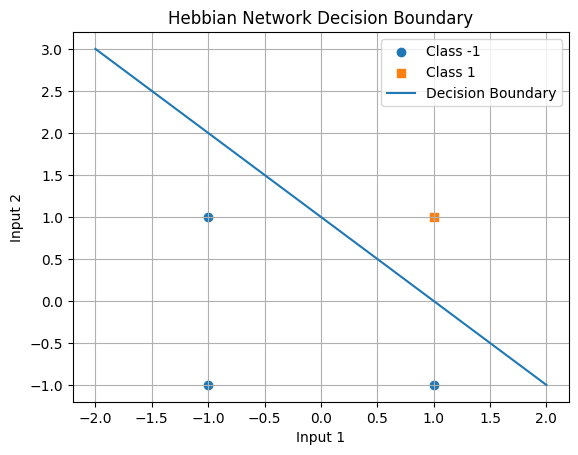

In [5]:
import numpy as np


def train_hebbian_network(X, Y, learning_rate=1.0):
   """
   Trains a single-layer Hebbian network.

   Args:
       X (np.array): Input patterns (including bias term if needed).
       Y (np.array): Target outputs.
       learning_rate (float): The learning rate (often 1.0 for basic Hebbian).

   Returns:
       np.array: The final trained weights.
   """
   # Initialize weights and bias to zero
   # The number of weights is equal to the number of input features + 1 (for bias)
   num_features = X.shape[1]
   weights = np.zeros(num_features)

   print(f"Initial weights: {weights}\n")


   # Iterate over all training samples to update weights
   for i in range(len(X)):
       x = X[i]
       y = Y[i]

       # Hebbian learning rule for weight update
       delta_w = learning_rate * x * y
       weights += delta_w

       print(f"Iteration {i+1} | Input: {x}, Target: {y}")
       print(f"Updated weights: {weights}\n")

   return weights


def predict(inputs, weights):
   """
   Predicts the output for a given input using the trained weights.
   Uses a simple threshold activation function (e.g., sign function for bipolar).
   """
   # Calculate the net input (dot product of inputs and weights)
   net_input = np.dot(inputs, weights)

   # Activation function: returns 1 if net_input > 0, otherwise -1 (or other threshold)
   return 1 if net_input > 0 else -1


# --- Example Usage: AND logic gate with bipolar values ---


# Input patterns with a bias term (the last column of 1s)
# Format: [input1, input2, bias]
X_train = np.array([
   [-1, -1, 1],
   [-1,  1, 1],
   [ 1, -1, 1],
   [ 1,  1, 1]
])


# Corresponding target outputs for the AND function
Y_train = np.array([-1, -1, -1, 1])


# Train the network
trained_weights = train_hebbian_network(X_train, Y_train)


# --- Test the network ---
print("--- Testing the Network ---")
for i in range(len(X_train)):
   inputs_with_bias = X_train[i]
   # Pass only the original inputs and bias for prediction
   prediction = predict(inputs_with_bias, trained_weights)
   original_inputs = inputs_with_bias[:2] # Exclude the bias term for printing inputs
   print(f"Input: {original_inputs}, Predicted Output: {prediction}, Expected: {Y_train[i]}")
# ---------------- GRAPH ----------------


# Remove bias column for plotting
X_plot = X_train[:, :2]


plt.scatter(X_plot[Y_train==-1][:,0], X_plot[Y_train==-1][:,1], marker='o', label="Class -1")
plt.scatter(X_plot[Y_train==1][:,0], X_plot[Y_train==1][:,1], marker='s', label="Class 1")


# Decision Boundary
w1, w2, b = trained_weights
x_vals = np.linspace(-2, 2, 100)
y_vals = -(w1*x_vals + b) / w2


plt.plot(x_vals, y_vals, label="Decision Boundary")


plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.title("Hebbian Network Decision Boundary")
plt.legend()
plt.grid(True)


plt.show()
